# Flight Delays


Millions of people fly every day, and flight delays can be an unwelcome aspect of air travel. Just how often do flight delays occur?

In this project, we will work with airport flight data and explore how the day of week affects the likelihood of a delayed departure.

### Loading the Data
The `'atlanta-airport-flights-2023.csv'` file contains a sample of domestic flights going out of the world's busiest airport.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
flights = pd.read_csv('flights.csv')
flights = flights.convert_dtypes()
pd.options.mode.chained_assignment = None
flights


,scheduled,actual,carrier,flight,tailnum,origin,dest,air_time,distance
0,"04/29/2023, 16:35","04/29/2023, 17:01",WN,1079,N230WN,ATL,HOU,110,696
1,"07/02/2023, 15:10","07/02/2023, 15:05",DL,355,N953AT,ATL,GPT,54,352
2,"12/25/2023, 10:55","12/25/2023, 10:53",WN,291,N413WN,ATL,RDU,57,356
3,"09/01/2023, 12:50","09/01/2023, 12:48",DL,1132,N947DZ,ATL,TYS,28,152
4,"12/14/2023, 07:05","12/14/2023, 07:02",DL,40,N332DN,ATL,BOS,121,946
...,...,...,...,...,...,...,...,...,...
4995,"11/15/2023, 14:20","11/15/2023, 14:17",WN,13,N400WN,ATL,MCO,63,404
4996,"04/09/2023, 19:50","04/09/2023, 19:58",OH,1320,N567NN,ATL,CLT,42,226
4997,"12/14/2023, 13:20","12/14/2023, 13:16",DL,695,N363NB,ATL,DAL,103,721
4998,"12/06/2023, 13:05","12/06/2023, 13:01",DL,911,N992AT,ATL,GSO,56,306


The `scheduled` column represents the time the flight was scheduled, but the actual departure time is represented by the `actual` column. null We can use these columns to calculate flight delays.
Let's begin by extracting the two departure time columns.


In [ ]:
departures = flights[['scheduled', 'actual']]
departures 

,scheduled,actual
0,"04/29/2023, 16:35","04/29/2023, 17:01"
1,"07/02/2023, 15:10","07/02/2023, 15:05"
2,"12/25/2023, 10:55","12/25/2023, 10:53"
3,"09/01/2023, 12:50","09/01/2023, 12:48"
4,"12/14/2023, 07:05","12/14/2023, 07:02"
...,...,...
4995,"11/15/2023, 14:20","11/15/2023, 14:17"
4996,"04/09/2023, 19:50","04/09/2023, 19:58"
4997,"12/14/2023, 13:20","12/14/2023, 13:16"
4998,"12/06/2023, 13:05","12/06/2023, 13:01"


In [21]:

departures.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype          
---  ------     --------------  -----          
 0   scheduled  5000 non-null   datetime64[us] 
 1   actual     5000 non-null   datetime64[us] 
 2   delay      5000 non-null   timedelta64[us]
 3   is_late    5000 non-null   bool           
 4   day_name   5000 non-null   str            
dtypes: bool(1), datetime64[us](2), str(1), timedelta64[us](1)
memory usage: 161.3 KB


The time values are currently strings.

Strings are not well suited for numerical calculations. For calculations that involves dates and times, we recommend converting those strings to datetime objects.

### Convert strings to datetime



In [5]:
departures['scheduled'] = pd.to_datetime(departures['scheduled'])
departures['actual'] = pd.to_datetime(departures['actual'])
departures #display

,scheduled,actual
0,2023-04-29 16:35:00,2023-04-29 17:01:00
1,2023-07-02 15:10:00,2023-07-02 15:05:00
2,2023-12-25 10:55:00,2023-12-25 10:53:00
3,2023-09-01 12:50:00,2023-09-01 12:48:00
4,2023-12-14 07:05:00,2023-12-14 07:02:00
...,...,...
4995,2023-11-15 14:20:00,2023-11-15 14:17:00
4996,2023-04-09 19:50:00,2023-04-09 19:58:00
4997,2023-12-14 13:20:00,2023-12-14 13:16:00
4998,2023-12-06 13:05:00,2023-12-06 13:01:00


In [6]:
departures.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   scheduled  5000 non-null   datetime64[us]
 1   actual     5000 non-null   datetime64[us]
dtypes: datetime64[us](2)
memory usage: 78.3 KB


Looks good! We now have datetime values that we can use to perform date and time calculations with.

# Calculate the delays

To identify the delayed flights, let's first calculate the amount of delay for each flight using our datetime columns. The equation for the amount of flight delay is:

`delay = actual − scheduled`



In [7]:
departures['delay'] = departures['actual'] - departures['scheduled']
departures #display

,scheduled,actual,delay
0,2023-04-29 16:35:00,2023-04-29 17:01:00,0 days 00:26:00
1,2023-07-02 15:10:00,2023-07-02 15:05:00,-1 days +23:55:00
2,2023-12-25 10:55:00,2023-12-25 10:53:00,-1 days +23:58:00
3,2023-09-01 12:50:00,2023-09-01 12:48:00,-1 days +23:58:00
4,2023-12-14 07:05:00,2023-12-14 07:02:00,-1 days +23:57:00
...,...,...,...
4995,2023-11-15 14:20:00,2023-11-15 14:17:00,-1 days +23:57:00
4996,2023-04-09 19:50:00,2023-04-09 19:58:00,0 days 00:08:00
4997,2023-12-14 13:20:00,2023-12-14 13:16:00,-1 days +23:56:00
4998,2023-12-06 13:05:00,2023-12-06 13:01:00,-1 days +23:56:00


We have a new `delay` column! The first flight in our dataframe left 26 minutes late. The second flight has a negative delay, indicating that it left 5 minutes early.

Airlines can leave a few minutes behind schedule without being considered late. Typically a flight is considered late if it departs more than 900 seconds (15 minutes) after the scheduled departure time.

Let's determine which flights are late?


In [ ]:
departures['is_late'] = departures['delay'].dt.total_seconds() > 900
departures 

,scheduled,actual,delay,is_late
0,2023-04-29 16:35:00,2023-04-29 17:01:00,0 days 00:26:00,True
1,2023-07-02 15:10:00,2023-07-02 15:05:00,-1 days +23:55:00,False
2,2023-12-25 10:55:00,2023-12-25 10:53:00,-1 days +23:58:00,False
3,2023-09-01 12:50:00,2023-09-01 12:48:00,-1 days +23:58:00,False
4,2023-12-14 07:05:00,2023-12-14 07:02:00,-1 days +23:57:00,False
...,...,...,...,...
4995,2023-11-15 14:20:00,2023-11-15 14:17:00,-1 days +23:57:00,False
4996,2023-04-09 19:50:00,2023-04-09 19:58:00,0 days 00:08:00,False
4997,2023-12-14 13:20:00,2023-12-14 13:16:00,-1 days +23:56:00,False
4998,2023-12-06 13:05:00,2023-12-06 13:01:00,-1 days +23:56:00,False


We now know which flights were delayed. Next up, calculating the day of week for each flight.

### Get the day of the week


In [9]:
departures['day_name'] = departures['actual'].dt.strftime('%a')
departures #display
departures.to_csv('departures-check-point.tsv', index=False, sep='\t')



Now that we have the days of the week, let's calculate the percentage of flights that are delayed for each day of the week.

### Percentage flights delayed by day of week

To calculate the percentage of flights that are delayed, let's take the `mean()` of the `is_late` column for each day of the week. The mean of a True/False column equals the proportion of True values, as shown here.

We will then convert this proportion to a percentage by multiplying by 100.


In [ ]:
proportion_delayed = departures.groupby('day_name')['is_late'].mean()
percent_delayed = proportion_delayed * 100
percent_delayed 

day_name
Fri    22.593583
Mon    20.185923
Sat    18.558282
Sun    23.376623
Thu    20.939597
Tue    15.419847
Wed    16.691285
Name: is_late, dtype: float64



These differences will be easier to see in a graph, so let's create a bar chart.

### Plot the data
To plot the data, let's first reorder percent_delayed in natural day of the week order (Sun-Sat).

In [11]:
new_index_order = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
percent_delayed = percent_delayed.reindex(new_index_order)
percent_delayed

day_name
Sun    23.376623
Mon    20.185923
Tue    15.419847
Wed    16.691285
Thu    20.939597
Fri    22.593583
Sat    18.558282
Name: is_late, dtype: float64

Percent delayed is now ordered from Sunday through Saturday. We have a clean dataset that we can plot.


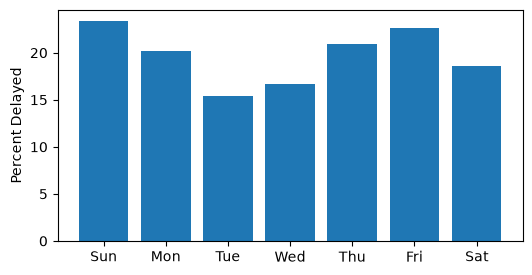

In [12]:
plt.figure(figsize=(6, 3))
plt.bar(percent_delayed.index, percent_delayed)
plt.ylabel('Percent Delayed')
plt.show()

The day of the week with the fewest late flights is Tuesday.

## Project extensions

Below is a proposed extension idea.

The file `us-daily-passengers.csv` contains data on the daily number of passengers flying in the United States throughout 2023.

Let's Create a graph that shows the average number of passengers flying per day of the week. Then, compare this graph to Our graph of the percentage of flights delayed by day of week.

In [14]:
passengers = pd.read_csv('us-daily-passengers.csv')
passengers.head()

,date,num_passengers
0,1/1/23,2046950
1,1/2/23,2368194
2,1/3/23,2212528
3,1/4/23,1985965
4,1/5/23,2031976


The `passengers` dataframe has been loaded. Let's inspect its data types to ensure the 'date' column is in the correct format for time-based operations.

In [16]:
passengers.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   date            365 non-null    str  
 1   num_passengers  365 non-null    int64
dtypes: int64(1), str(1)
memory usage: 5.8 KB


As expected, the 'date' column is currently an object (string). We need to convert it to a datetime object to enable time-based operations such as extracting the day of the week.

In [27]:
passengers['date'] = pd.to_datetime(passengers['date'],format='%d/%m/%y')
passengers.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            365 non-null    datetime64[us]
 1   num_passengers  365 non-null    int64         
 2   day_name        365 non-null    str           
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 8.7 KB


The 'date' column has now been successfully converted to `datetime64[ns]`. Now we can extract the day of the week from this column. We'll use the abbreviated weekday name, consistent with the `departures` DataFrame, and then calculate the average number of passengers for each day.

In [28]:
passengers['day_name'] = passengers['date'].dt.strftime('%a')

avg_passengers_per_day = passengers.groupby('day_name')['num_passengers'].mean()
avg_passengers_per_day = avg_passengers_per_day.reindex(new_index_order)
avg_passengers_per_day

day_name
Sun    2.506567e+06
Mon    2.442001e+06
Tue    2.098239e+06
Wed    2.210753e+06
Thu    2.489463e+06
Fri    2.547110e+06
Sat    2.168205e+06
Name: num_passengers, dtype: float64

We have calculated the average number of passengers for each day of the week and reindexed the series to ensure the days are in the correct order (Sun-Sat). This will make our visualization consistent. We can see that weekend days generally have higher average passenger numbers, with Monday and Friday also being quite high.

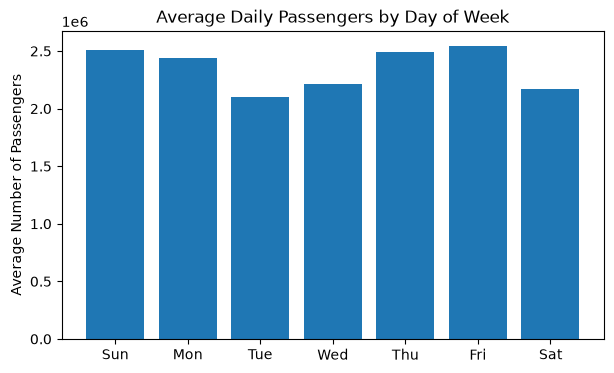

In [29]:
plt.figure(figsize=(7, 4))
plt.bar(avg_passengers_per_day.index, avg_passengers_per_day)
plt.ylabel('Average Number of Passengers')
plt.title('Average Daily Passengers by Day of Week')
plt.show()

The bar chart clearly visualizes the average number of passengers per day. We can observe peaks on Sundays and Mondays, followed by a slight dip mid-week, and then another rise towards Friday and Saturday. This pattern suggests higher travel demand around weekends and the beginning/end of the work week.

Now, let's compare the percentage of flights delayed by day of the week with the average number of passengers per day of the week. This will allow us to identify any potential relationships or patterns between passenger volume and flight delays.

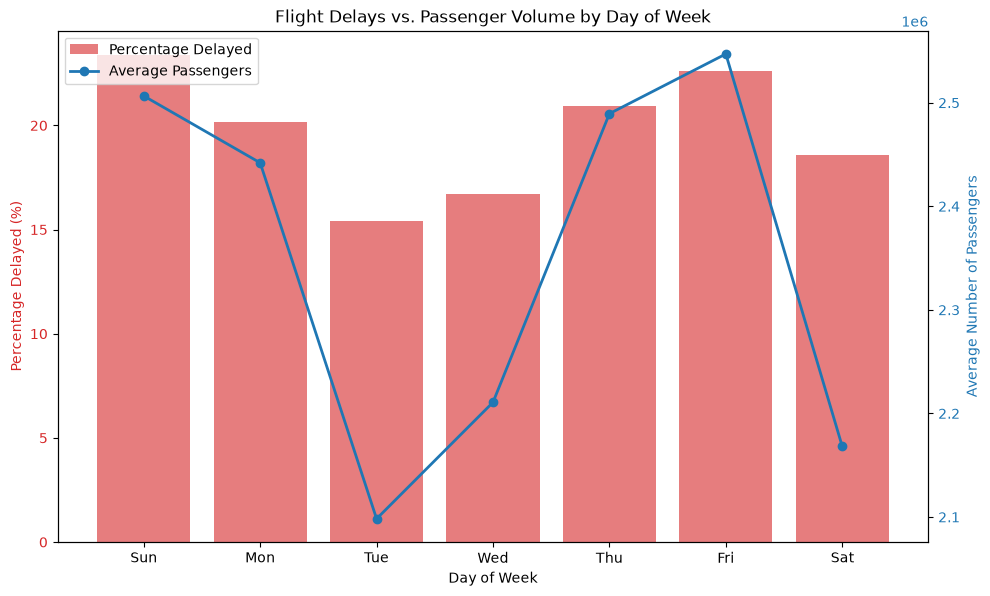

In [26]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Day of Week')
ax1.set_ylabel('Percentage Delayed (%)', color=color)
ax1.bar(percent_delayed.index, percent_delayed, color=color, alpha=0.6, label='Percentage Delayed')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Average Number of Passengers', color=color)
ax2.plot(avg_passengers_per_day.index, avg_passengers_per_day, color=color, marker='o', linestyle='-', linewidth=2, label='Average Passengers')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout() 
plt.title('Flight Delays vs. Passenger Volume by Day of Week')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

This combined plot allows for a direct comparison between the percentage of delayed flights and the average number of passengers each day. We can observe some interesting patterns:

*   **Weekends and Mondays:** Both passenger volume and delay percentages tend to be higher on Sundays and Mondays. This suggests that increased passenger traffic on these days might contribute to a higher likelihood of flight delays.
*   **Mid-week Dip:** Tuesdays and Wednesdays show the lowest percentage of delays, which correlates with a noticeable dip in average passenger numbers. This reinforces the idea that fewer passengers might lead to a smoother operation and fewer delays.
*   **Friday Peak:** Fridays show a significant increase in both passenger volume and delay percentages, similar to the beginning of the week. This is likely due to weekend travel starting on Friday.

Overall, there appears to be a positive correlation: days with higher passenger volumes tend to experience a higher percentage of flight delays.

# Final Conclusion

This project analyzed flight departure delays using a dataset of flights from Atlanta Airport and compared it with US daily passenger data. The main objective was to understand how the day of the week affects flight delays and whether passenger volume plays a role.

**Key Findings:**

1.  **Delay Calculation:** By converting `scheduled` and `actual` departure times to datetime objects, we successfully calculated the `delay` for each flight and identified flights considered `late` (delayed by more than 15 minutes).
2.  **Day of Week Delays:** The percentage of flight delays varied significantly across the week. Sundays, Mondays, and Fridays exhibited the highest percentages of delays, while Tuesdays and Wednesdays had the lowest.
3.  **Passenger Volume Patterns:** The analysis of US daily passenger data revealed that passenger volumes also followed a weekly pattern, with peaks on Sundays, Mondays, and Fridays, and dips mid-week.
4.  **Correlation between Passengers and Delays:** A clear positive correlation was observed between the average number of passengers and the percentage of flight delays. Days with higher passenger traffic (Sundays, Mondays, Fridays) generally experienced more delays, while days with lower traffic (Tuesdays, Wednesdays) had fewer delays.

**Overall Takeaway:**

This analysis suggests that **passenger volume is a significant factor contributing to flight delays**. Days with higher travel demand, particularly around weekends and the start/end of the work week, tend to strain airport operations, leading to a higher incidence of delayed departures. Airlines and airports could potentially use this insight to optimize scheduling, staffing, and resource allocation on high-traffic days to mitigate delays and improve passenger experience.